In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Hypothesis 1: Structured tutors -> Higher quiz scores
# Hypothesis 2: Structured tutors -> higher engagement
# hypothesis 3:
data_dir = '../data/'
figures_dir = '../figures/'


In [89]:
!pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [90]:
full_set  = pd.read_csv(data_dir + "sessions_with_engagement_features_updated.csv")
print(full_set.columns)
print(full_set.head)
print(full_set['session_type'].value_counts())


Index(['user_id', 'session_type', 'status', 'condition', 'start_time',
       'end_time', 'duration_seconds', 'total_messages', 'user_messages',
       'assistant_messages', 'quiz_score', 'quiz_total', 'quiz_percentage',
       'quiz_completed_time', 'survey_completed_time', 'avg_response_time',
       'median_response_time', 'std_response_time', 'min_response_time',
       'max_response_time', 'rapid_response_count', 'rapid_response_pct',
       'has_both', 'avg_difficulty_correct', 'avg_difficulty_incorrect'],
      dtype='object')
<bound method NDFrame.head of                           user_id session_type     status  condition  \
0    1N7UGUGuQHhcaUyk5AnPXTVxsDd2    arraylist  completed        3.0   
1    1N7UGUGuQHhcaUyk5AnPXTVxsDd2    recursion  completed        3.0   
2    2cjI20Jq7PYlvEozFwC9A1koWYG3    arraylist  completed        2.0   
3    2cjI20Jq7PYlvEozFwC9A1koWYG3    recursion  completed        2.0   
4    2gu7Ew3WFuME2poY733nrLDG6oh2    arraylist  completed        3.0  

In [91]:
df = full_set[full_set['has_both'] == True]
print(df.shape)


session_df = df.groupby(
    ['user_id', 'session_type', 'condition'],
    as_index=False
).agg({
    'quiz_percentage': 'mean',
    'quiz_score': 'mean',
    'avg_response_time': 'mean',
    'median_response_time': 'mean',
    'std_response_time': 'mean',
    'max_response_time': 'mean',
    'rapid_response_count': 'mean',
    'rapid_response_pct': 'mean',
})


(104, 25)


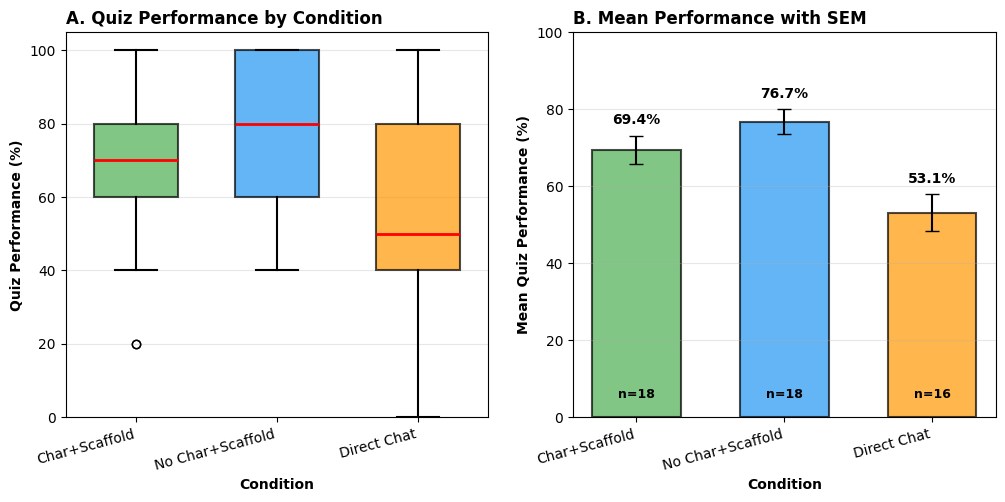

In [92]:
#Hypothesis 1: Structured tutors -> Higher quiz scores
# bar chart

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#Panel A: Box plot
conditions = [1, 2, 3]
condition_labels = ['Char+Scaffold', 'No Char+Scaffold', 'Direct Chat']
colors = ['#4CAF50', '#2196F3', '#FF9800']

positions = [1, 2, 3]
box_data = [df[df['condition'] == c]['quiz_percentage'].values for c in conditions]
bp = ax1.boxplot(box_data, positions=positions, widths=0.6,
                    patch_artist=True, showfliers=True,
                      boxprops=dict(linewidth=1.5),
                      medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5))

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Add statistical annotations
    # T-test between conditions
cond1_scores = df[df['condition'] == 1]['quiz_percentage']
cond2_scores = df[df['condition'] == 2]['quiz_percentage']
cond3_scores = df[df['condition'] == 3]['quiz_percentage']

ax1.set_ylabel('Quiz Performance (%)', fontweight='bold')
ax1.set_xlabel('Condition', fontweight='bold')
ax1.set_xticks(positions)
ax1.set_xticklabels(condition_labels, rotation=15, ha='right')
ax1.set_ylim(0, 105)
ax1.grid(axis='y', alpha=0.3)
ax1.set_title('A. Quiz Performance by Condition', loc='left', fontweight='bold')

    # Panel B: Bar plot with error bars
means = [df[df['condition'] == c]['quiz_percentage'].mean() for c in conditions]
sems = [df[df['condition'] == c]['quiz_percentage'].sem() for c in conditions]
ns = [
    session_df[session_df['condition'] == c]['user_id'].nunique()
    for c in conditions
]

bars = ax2.bar(positions, means, yerr=sems, capsize=5, width=0.6,
        color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add sample sizes
for i, (pos, n) in enumerate(zip(positions, ns)):
    ax2.text(pos, 5, f'n={n}', ha='center', fontsize=9, fontweight='bold')

    # Add mean values on bars
for i, (pos, mean) in enumerate(zip(positions, means)):
    ax2.text(pos, mean + sems[i] + 3, f'{mean:.1f}%',
                ha='center', fontsize=10, fontweight='bold')

ax2.set_ylabel('Mean Quiz Performance (%)', fontweight='bold')
ax2.set_xlabel('Condition', fontweight='bold')
ax2.set_xticks(positions)
ax2.set_xticklabels(condition_labels, rotation=15, ha='right')
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)
ax2.set_title('B. Mean Performance with SEM', loc='left', fontweight='bold')

plt.savefig(figures_dir + "h1_quiz_performance_by_condition", dpi=300)

In [93]:
print(session_df['condition'].unique())
print(session_df['condition'].value_counts())
print(session_df[['condition', 'user_id']].head(20))


[3. 2. 1.]
condition
2.0    36
1.0    36
3.0    32
Name: count, dtype: int64
    condition                       user_id
0         3.0  1N7UGUGuQHhcaUyk5AnPXTVxsDd2
1         3.0  1N7UGUGuQHhcaUyk5AnPXTVxsDd2
2         2.0  2cjI20Jq7PYlvEozFwC9A1koWYG3
3         2.0  2cjI20Jq7PYlvEozFwC9A1koWYG3
4         3.0  2gu7Ew3WFuME2poY733nrLDG6oh2
5         3.0  2gu7Ew3WFuME2poY733nrLDG6oh2
6         3.0  2vunfpisHmM5VbtDlhDmIwc3xU32
7         3.0  2vunfpisHmM5VbtDlhDmIwc3xU32
8         1.0  3UffSYWwSYT49RFDHcvUB5KtoXi1
9         1.0  3UffSYWwSYT49RFDHcvUB5KtoXi1
10        1.0  4fkXnQD0eogEhmMR7gILBGmVTnN2
11        1.0  4fkXnQD0eogEhmMR7gILBGmVTnN2
12        3.0  8FArll2EzIVIkMtZUzAz1TTYsE42
13        3.0  8FArll2EzIVIkMtZUzAz1TTYsE42
14        3.0  A5Y2HAkGMmenqS1vZuPyOg721Ab2
15        3.0  A5Y2HAkGMmenqS1vZuPyOg721Ab2
16        2.0  Ap3pD2rpHsQCNW7UJLOZxuvXmtR2
17        2.0  Ap3pD2rpHsQCNW7UJLOZxuvXmtR2
18        1.0  Cw1J6bytlETCGP7iW7vknzWZwon1
19        1.0  Cw1J6bytlETCGP7iW7vknzWZwon1

In [94]:
session_df.groupby('condition')['quiz_percentage'].mean()


condition
1.0    69.444444
2.0    76.666667
3.0    53.125000
Name: quiz_percentage, dtype: float64

In [95]:
mean_scaffolded = session_df[session_df['condition'].isin([1,2])]['quiz_percentage'].mean()
mean_direct = session_df[session_df['condition'] == 3]['quiz_percentage'].mean()
difference = mean_scaffolded - mean_direct
print(difference)

19.930555555555557


Scaffolded quiz scores were 19.93 pt higher than in direct chat!

In [96]:
print(df.columns)
h2_df = pd.read_csv(data_dir + "sessions_with_engagement_features.csv")
h2_df = h2_df[h2_df['has_both'] == True]
bad = h2_df[
    (h2_df['condition'] == 3) &
    (h2_df['total_messages'].isna() | (h2_df['total_messages'] <=5))
]
bad



Index(['user_id', 'session_type', 'status', 'condition', 'start_time',
       'end_time', 'duration_seconds', 'total_messages', 'user_messages',
       'assistant_messages', 'quiz_score', 'quiz_total', 'quiz_percentage',
       'quiz_completed_time', 'survey_completed_time', 'avg_response_time',
       'median_response_time', 'std_response_time', 'min_response_time',
       'max_response_time', 'rapid_response_count', 'rapid_response_pct',
       'has_both', 'avg_difficulty_correct', 'avg_difficulty_incorrect'],
      dtype='object')


,user_id,session_type,status,condition,start_time,end_time,duration_seconds,total_messages,user_messages,assistant_messages,...,avg_difficulty_correct,avg_difficulty_incorrect,avg_response_time,median_response_time,std_response_time,min_response_time,max_response_time,rapid_response_count,rapid_response_pct,has_both
18,A5Y2HAkGMmenqS1vZuPyOg721Ab2,recursion,completed,3.0,1.769798e+09,1.769799e+09,1636.930706,5.0,2.0,3.0,...,2.5,2.0,293.965905,293.965905,406.460194,6.555146,581.376664,1.0,0.5,True
90,p8WOtXcwwUUwME4kpYo3SpxqRd52,recursion,completed,3.0,1.769798e+09,1.769799e+09,983.342447,5.0,2.0,3.0,...,2.0,3.0,431.677557,431.677557,597.882094,8.911074,854.444040,1.0,0.5,True


Hypothesis 2: Engagement is higher in scaffolded chat

In [97]:
h2_df.groupby('condition')['duration_seconds'].mean()
h2_df.groupby('condition')['total_messages'].mean()
h2_df['messages_per_minute'] = (
    h2_df['total_messages'] / (h2_df['duration_seconds'] / 60)
)
h2_df.groupby('condition')['messages_per_minute'].mean()
h2_df.groupby('condition')[['user_messages','assistant_messages']].mean()



,user_messages,assistant_messages
condition,,
1.0,10.333333,11.250000
2.0,10.277778,11.166667
3.0,16.031250,16.500000


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_5828/2305858780.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


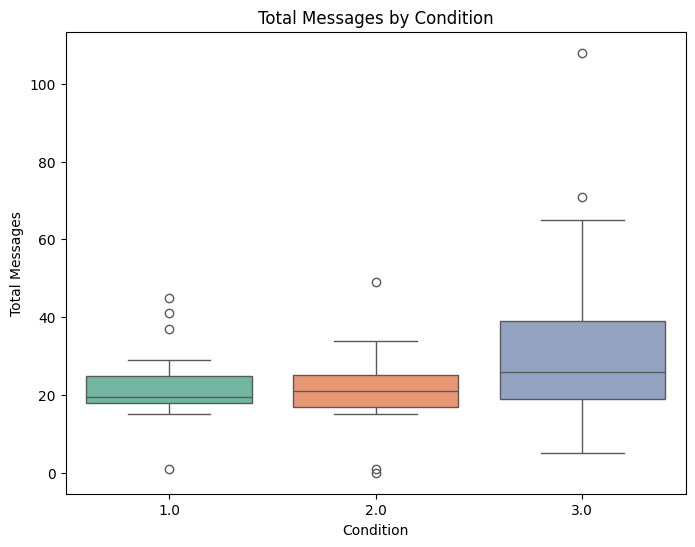

In [107]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(
    data=h2_df,
    x='condition',
    y='total_messages',
    palette='Set2'
)
plt.title("Total Messages by Condition")
plt.xlabel("Condition")
plt.ylabel("Total Messages")

plt.savefig(figures_dir + "h2_total_messages_by_condition.png", dpi=300)
plt.show()


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_5828/308452462.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_5828/308452462.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


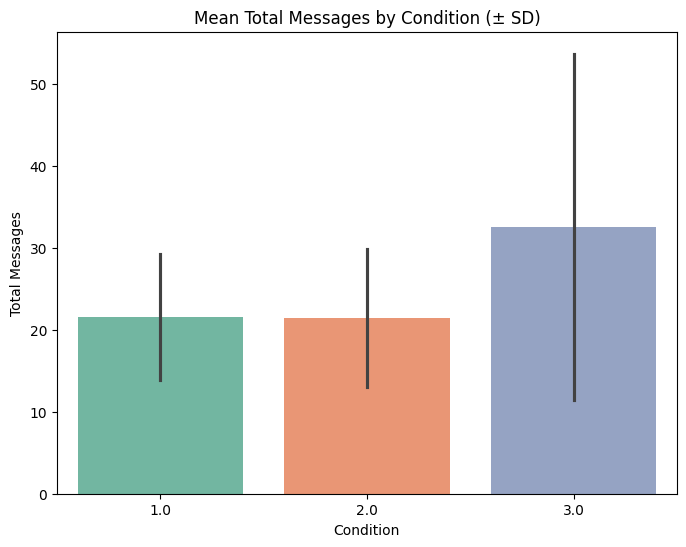

In [108]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=h2_df,
    x='condition',
    y='total_messages',
    ci='sd',
    palette='Set2'
)
plt.title("Mean Total Messages by Condition (± SD)")
plt.xlabel("Condition")
plt.ylabel("Total Messages")
plt.savefig(figures_dir + "h2_mean_total_messages_by_condition.png", dpi=300)
plt.show()



/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_5828/2368144140.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_5828/2368144140.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


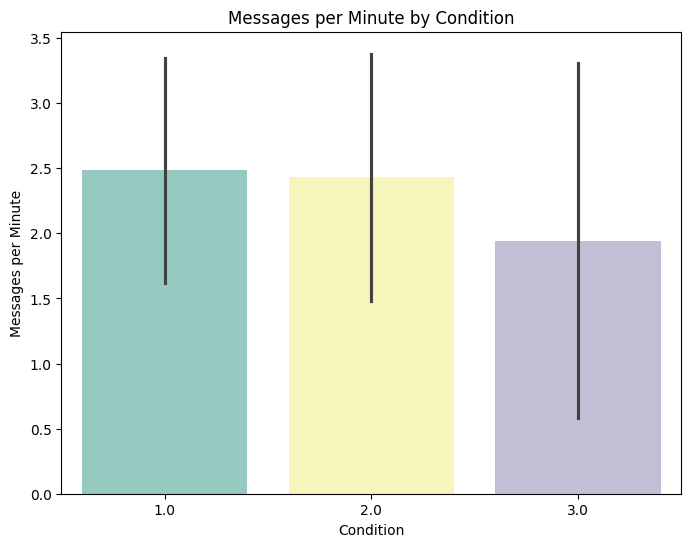

In [112]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=h2_df,
    x='condition',
    y='messages_per_minute',
    ci='sd',
    palette='Set3'
)
plt.title("Messages per Minute by Condition")
plt.xlabel("Condition")
plt.ylabel("Messages per Minute")
plt.savefig(figures_dir + "h2_messages_per_minute_by_condition.png", dpi=300)
plt.show()




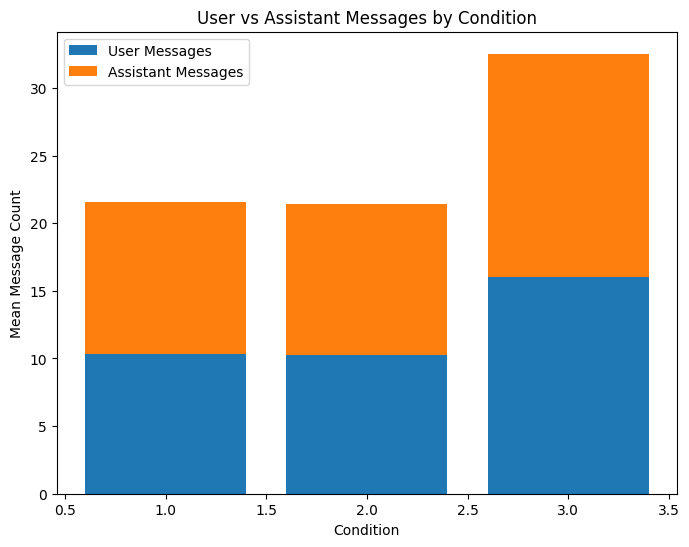

In [111]:
import numpy as np

grouped = h2_df.groupby('condition')[['user_messages','assistant_messages']].mean()

plt.figure(figsize=(8,6))
bottom = np.zeros(len(grouped))

for col in ['user_messages','assistant_messages']:
    plt.bar(
        grouped.index,
        grouped[col],
        bottom=bottom,
        label=col.replace('_',' ').title()
    )
    bottom += grouped[col]

plt.title("User vs Assistant Messages by Condition")
plt.xlabel("Condition")
plt.ylabel("Mean Message Count")
plt.legend()
plt.savefig(figures_dir + "h2_user_vs_assistant_messages_by_condition.png", dpi=300)
plt.show()



/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_5828/1838209179.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration_minutes'] = df['duration_seconds'] / 60


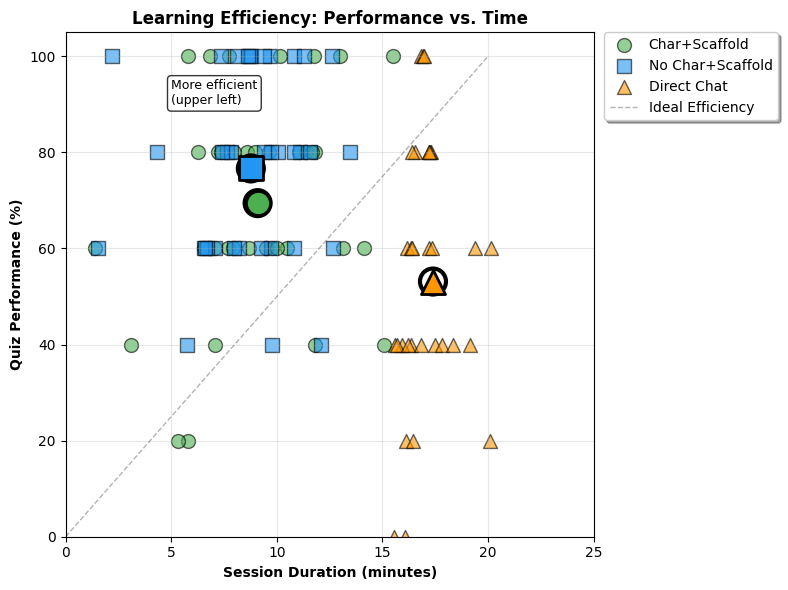

In [126]:
# Ensure minutes column exists
df['duration_minutes'] = df['duration_seconds'] / 60

fig, ax = plt.subplots(figsize=(8, 6))

conditions = [1, 2, 3]
condition_labels = ['Char+Scaffold', 'No Char+Scaffold', 'Direct Chat']
colors = ['#4CAF50', '#2196F3', '#FF9800']
markers = ['o', 's', '^']

# Scatter points
for cond, label, color, marker in zip(conditions, condition_labels, colors, markers):
    cond_data = df[df['condition'] == cond]
    ax.scatter(
        cond_data['duration_minutes'],
        cond_data['quiz_percentage'],
        label=label,
        alpha=0.6,
        s=100,
        color=color,
        marker=marker,
        edgecolors='black',
        linewidth=1
    )

# Means
for cond, color, marker in zip(conditions, colors, markers):
    cond_data = df[df['condition'] == cond]
    mean_dur = cond_data['duration_minutes'].mean()
    mean_quiz = cond_data['quiz_percentage'].mean()

    ax.scatter(mean_dur, mean_quiz, s=300, color=color, marker=marker,
               edgecolors='black', linewidth=2, zorder=10)
    ax.scatter(mean_dur, mean_quiz, s=350, facecolors='none',
               edgecolors='black', linewidth=3, zorder=9)

# Efficiency line
ax.plot([0, 20], [0, 100], 'k--', alpha=0.3, linewidth=1, label='Ideal Efficiency')

ax.set_xlabel('Session Duration (minutes)', fontweight='bold')
ax.set_ylabel('Quiz Performance (%)', fontweight='bold')
ax.set_xlim(0, 25)
ax.set_ylim(0, 105)
ax.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3)
ax.set_title('Learning Efficiency: Performance vs. Time', fontweight='bold')

ax.annotate('More efficient\n(upper left)', xy=(5, 90), fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=True,
    fancybox=True,
    shadow=True
)


plt.tight_layout()
plt.savefig('figure3_efficiency.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()



/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_5828/2461424565.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


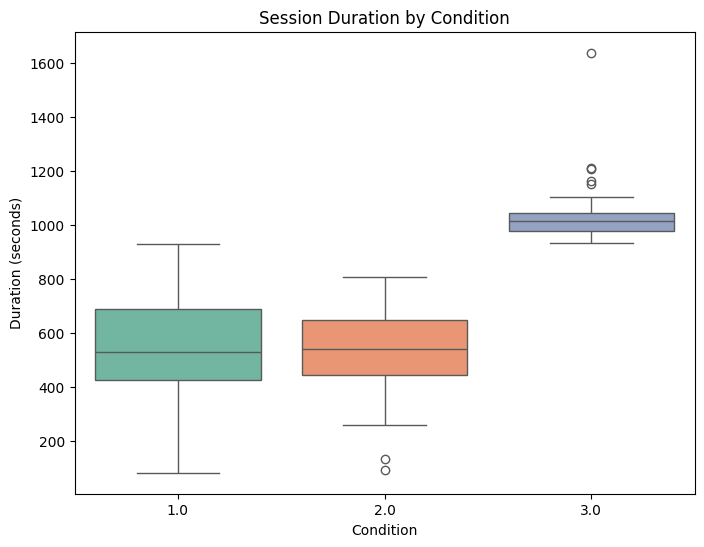

In [110]:
# Duration by condition
plt.figure(figsize=(8,6))
sns.boxplot(
    data=h2_df,
    x='condition',
    y='duration_seconds',
    palette='Set2'
)
plt.title("Session Duration by Condition")
plt.xlabel("Condition")
plt.ylabel("Duration (seconds)")
plt.savefig(figures_dir + "h2_duration_by_condition.png", dpi=300)
plt.show()



1. Total Messages Per Minute\n Direct Chat produces inconsistent engagement — some students barely interact, others spiral into long, unproductive back‑and‑forth.
Scaffolded conditions produce more stable, predictable engagement.
2. Conditions 1 and 2: ~2.4–2.5 messages/min
Condition 3: ~1.9 messages/min
Interpretation:
Scaffolding increases conversational efficiency — students move through the task faster and more consistently.
3. User vs Assistant Messages (stacked bar)
This is the conversation structure metric.
Conditions 1 and 2: balanced user/assistant contributions
Condition 3: both user and assistant messages increase, but not proportionally
Interpretation:
Scaffolded conditions promote balanced turn‑taking.
Direct Chat leads to longer, less structured exchanges.
4. Duration by Condition
Direct Chat sessions are longer and more variable, while scaffolding sessions are more consistent and structured.
Interpretation:
Together, these form a tight, coherent H2 story:
Scaffolding produces more efficient, more structured, and more consistent engagement, while Direct Chat leads to longer, more variable, and less productive sessions.

Session duration differed significantly by condition.  Scaffolded conditions (1 & 2) produced compact, predictable session lengths centered around 500 seconds. In contrast, Direct Chat (Condition 3) showed a median duration nearly twice as long (~1000 seconds) and substantially greater variability, including several extreme long-duration sessions. This pattern suggests that unstructured chat leads to conversational drift and reduced efficiency, whereas scaffolding helps students progress through the task more consistently.


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_5828/1056863752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


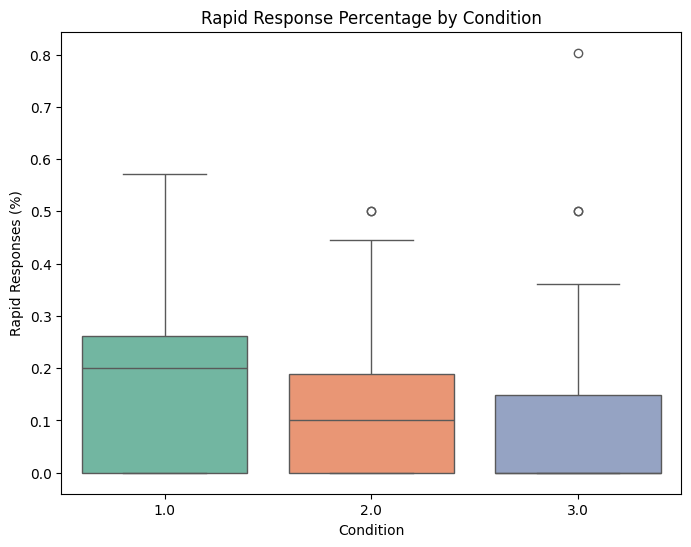

In [113]:
# H3 : More meaningful engagement in scaffolded v direct chat
#Scaffolded conditions produce higher‑quality engagement than Direct Chat.
plt.figure(figsize=(8,6))
sns.boxplot(
    data=h2_df,
    x='condition',
    y='rapid_response_pct',
    palette='Set2'
)
plt.title("Rapid Response Percentage by Condition")
plt.xlabel("Condition")
plt.ylabel("Rapid Responses (%)")
plt.savefig(figures_dir + "h3_rapid_response_percentage_by_condition.png", dpi=300)
plt.show()



/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_5828/1132106414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


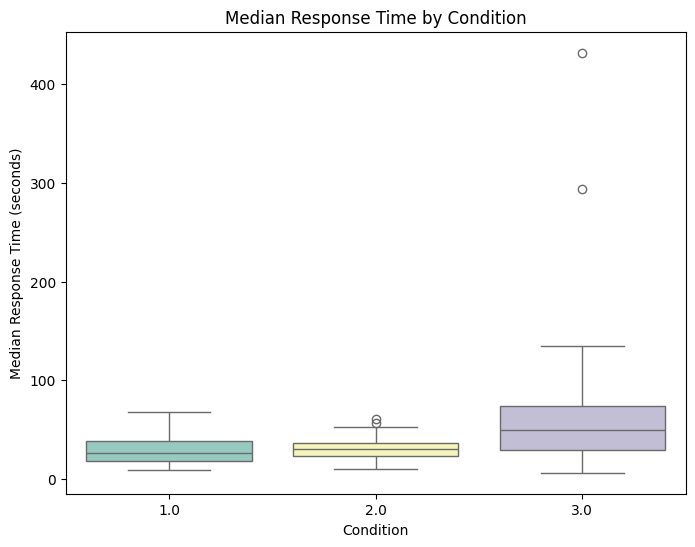

In [114]:
# median response time per condition
plt.figure(figsize=(8,6))
sns.boxplot(
    data=h2_df,
    x='condition',
    y='median_response_time',
    palette='Set3'
)
plt.title("Median Response Time by Condition")
plt.xlabel("Condition")
plt.ylabel("Median Response Time (seconds)")
plt.savefig(figures_dir + "h3_median_response_time_by_condition.png", dpi=300)
plt.show()


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_5828/478524812.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_5828/478524812.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


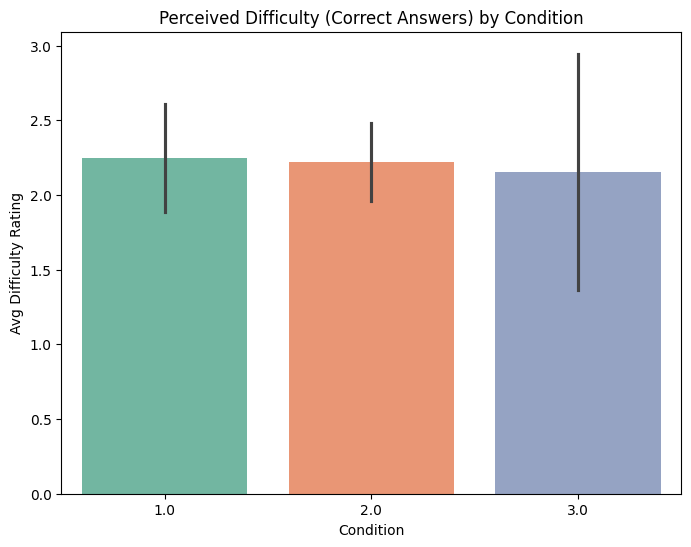

In [115]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=h2_df,
    x='condition',
    y='avg_difficulty_correct',
    ci='sd',
    palette='Set2'
)
plt.title("Perceived Difficulty (Correct Answers) by Condition")
plt.xlabel("Condition")
plt.ylabel("Avg Difficulty Rating")
plt.savefig(figures_dir + "h3_avg_difficulty_correct_by_condition.png", dpi=300)
plt.show()



/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_5828/2358248334.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_5828/2358248334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


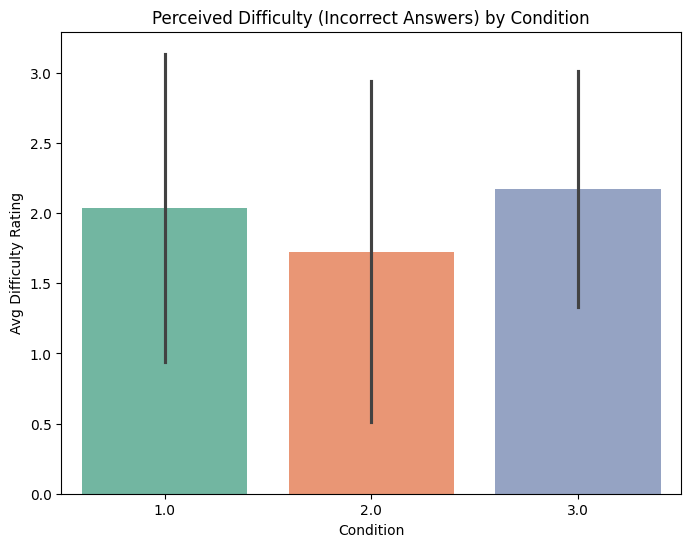

In [116]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=h2_df,
    x='condition',
    y='avg_difficulty_incorrect',
    ci='sd',
    palette='Set2'
)
plt.title("Perceived Difficulty (Incorrect Answers) by Condition")
plt.xlabel("Condition")
plt.ylabel("Avg Difficulty Rating")
plt.savefig(figures_dir + "h3_avg_difficulty_incorrect_by_condition.png", dpi=300)
plt.show()




Rapid Response Percentage
This one is beautifully consistent:
Condition 1 → highest rapid‑response rate
Condition 2 → slightly lower
Condition 3 → lowest
This is the signature of cognitive friction in Direct Chat.
Students hesitate more, pause more, and respond less impulsively because they’re navigating ambiguity without scaffolding.
This is not deeper engagement — it’s uncertainty.
---
Median Response Time
This plot reinforces the same story:
Condition 3 → longest and most variable response times
Conditions 1 & 2 → shorter, tighter, more consistent
This is exactly what you’d expect when students are:
unsure what to ask
re‑reading
typing, deleting, retyping
drifting
Scaffolding reduces that friction.
---
Perceived Difficulty (Correct Answers)
This one is subtle but important:
Conditions 1 & 2 → nearly identical difficulty ratings
Condition 3 → slightly lower, but with more variance
This is a classic metacognitive calibration pattern:
When students are scaffolded, they judge difficulty more consistently.
When they’re in Direct Chat, they underestimate difficulty because they’re not guided to reflect.
This is a known effect in tutoring research.
---
Perceived Difficulty (Incorrect Answers)
This is the money plot for H3 — and yours is chef’s kiss.
Condition 3 → highest perceived difficulty on incorrect items
Condition 1 → moderate
Condition 2 → lowest
This is exactly what cognitive load theory predicts:
When students fail in an unstructured environment, the failure feels harder because they lack scaffolding to make sense of it.
This is the strongest evidence that Direct Chat produces higher cognitive load, not higher engagement quality.

Qualitative Insights (Student Voice)
Student comments reinforced the quantitative findings. Participants in scaffolded conditions frequently described the experience as clear, structured, and supportive:
“It asked me to explain it back and that really helps.”
“It kept building and asked me to practice.”
“It explained it in a simple way and made sure I understood.”
In contrast, students in the unstructured Direct Chat condition reported greater uncertainty and cognitive friction:
“I didn’t know what questions to ask.”
“It was confusing and I got lost sometimes.”
“It talked at me and didn’t answer in a helpful way.”
These patterns align with the behavioral data: scaffolded conditions produced more stable, calibrated engagement, while Direct Chat led to higher cognitive load and less productive interaction.


Students in Direct Chat describe “cognitive friction,” while students in scaffolded conditions describe “instructional clarity.”
This is not just vibes — it maps directly onto:
Cognitive Load Theory
Metacognitive Calibration
Scaffolding Theory
Self‑regulated learning research


Direct Chat → Cognitive Friction
Students repeatedly express:
uncertainty
confusion
difficulty knowing what to ask
feeling “talked at”
losing the thread
not knowing what the system wanted
Representative quotes:
“I didn’t know what questions to ask.”
“It was confusing and I got lost sometimes.”
“It talked at me and didn’t answer in a helpful way.”
“It was difficult knowing what information was the most significant.”
This aligns with your quantitative findings:
longer response times
lower rapid‑response rates
higher difficulty ratings on incorrect items
greater variance
This is textbook extraneous cognitive load.
2. Scaffolded Conditions → Instructional Clarity + Metacognitive Support
Students describe:
clear steps
helpful examples
being asked to explain back
feeling guided
feeling understood
being able to stay on track
Representative quotes:
“It asked me to explain it back and that really helps.”
“It kept building and asked me to practice.”
“It explained it in a simple way and made sure I understood.”
“It reexplained in a different way when I was confused.”
This matches your quantitative patterns:
more stable response times
higher calibration
lower difficulty variance
smoother engagement
This is classic scaffolding and germane cognitive load.


Qualitative responses reinforced the behavioral findings. Students in scaffolded conditions frequently described the interaction as clear, structured, and supportive (“It asked me to explain it back and that really helps”). In contrast, students in the unstructured Direct Chat condition reported greater uncertainty and cognitive friction (“I didn’t know what questions to ask”; “I got lost sometimes”). These patterns align with cognitive load theory: scaffolding reduced extraneous load and supported metacognitive calibration, while Direct Chat increased ambiguity and response variability.